# Shallow-Squat Depth-Error Detection — EDA

Dataset characterization for the Squat **shallow-depth** image error on the **Fitness-AQA** official splits (Parmar et al., ECCV 2022): single-frame crops with one binary label each (shallow-depth present / deep-enough). Covers split sizes, class balance, and crop geometry behind the single-binary-head image classifier.

Reads the local Fitness-AQA Shallow-Squat archive (research-use only; not committed). Crops are decoded in-memory from `images.zip` — none are written to disk.

## Setup — locate the Shallow-Squat labeled archive

In [1]:
import io
import json
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

_REL = ("Fitness-AQA/Fitness-AQA_dataset_release-20260518T073812Z-3-001/"
        "Fitness-AQA_dataset_release/Squat/Labeled_Dataset/Shallow_Squat_Error_Dataset")
_CANDS = [Path(_REL), Path("../../") / _REL]
LAB = next((p for p in _CANDS if p.exists()), None)
assert LAB is not None, "local Shallow-Squat archive not found"
print("archive:", LAB)

FIG = Path("docs/figures") if Path("docs/figures").exists() else Path("../../docs/figures")
FIG.mkdir(parents=True, exist_ok=True)

labels = json.load(open(LAB / "labels_shallow_depth.json"))
splits = {s: json.load(open(LAB / "splits" / f"{s}_ids.json")) for s in ("train", "val", "test")}
print("label entries:", len(labels))
print("split counts:", {s: len(k) for s, k in splits.items()})

archive: ..\..\Fitness-AQA\Fitness-AQA_dataset_release-20260518T073812Z-3-001\Fitness-AQA_dataset_release\Squat\Labeled_Dataset\Shallow_Squat_Error_Dataset
label entries: 3611
split counts: {'train': 2542, 'val': 529, 'test': 540}


## 1. Official split sizes

3,611 labeled crops, used verbatim — no reshuffle, identical to the paper's protocol.

train: 2542 crops
  val: 529 crops
 test: 540 crops
total: 3611


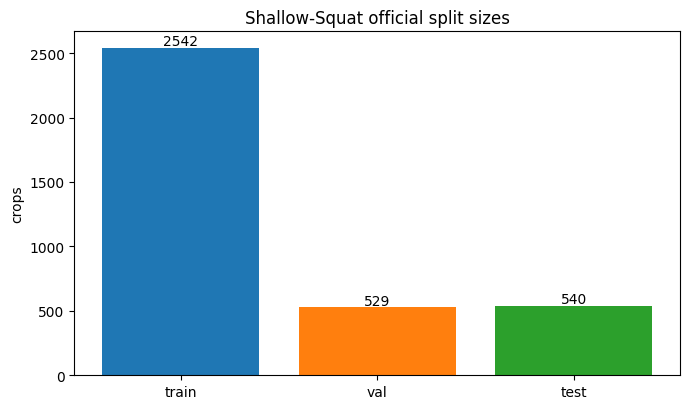

In [2]:
for s in ("train", "val", "test"):
    print(f"{s:>5}: {len(splits[s])} crops")
print("total:", sum(len(k) for k in splits.values()))

x = np.arange(3)
fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.bar(x, [len(splits[s]) for s in ("train", "val", "test")],
              color=["C0", "C1", "C2"])
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 20,
            str(int(b.get_height())), ha="center")
ax.set_xticks(x)
ax.set_xticklabels(["train", "val", "test"])
ax.set_ylabel("crops")
ax.set_title("Shallow-Squat official split sizes")
fig.tight_layout()
plt.show()

## 2. Class balance

Overall **43.9% positive** (1584/3611 shallow-depth) — a near-balanced task, unlike the
Squat **KIE** error (~14% positive). The near-50/50 split means a plain `BCEWithLogitsLoss`
without aggressive `pos_weight` is appropriate; F1 is still the reported metric for parity
with the paper.

overall positive: 1584/3611 = 43.9%
train: 1099/2542 = 43.2% positive
  val: 249/529 = 47.1% positive
 test: 236/540 = 43.7% positive


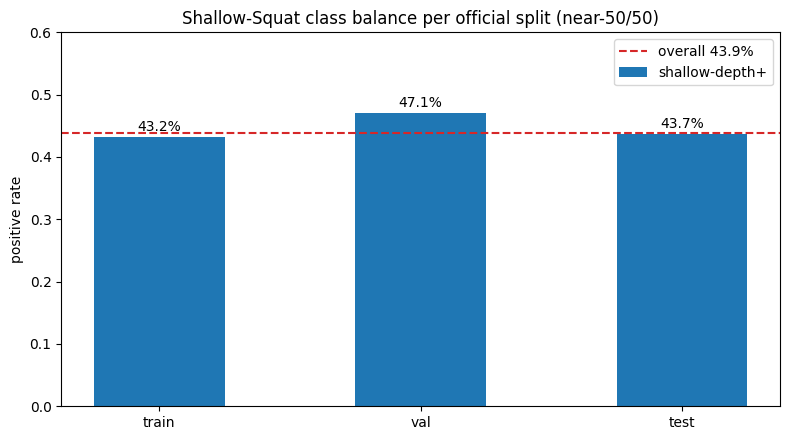

In [3]:
overall_pos = sum(int(labels[i]) for i in labels)
print(f"overall positive: {overall_pos}/{len(labels)} = {overall_pos / len(labels) * 100:.1f}%")
rates = {s: np.mean([labels[i] for i in ks]) for s, ks in splits.items()}
for s in ("train", "val", "test"):
    n_pos = sum(labels[i] for i in splits[s])
    print(f"{s:>5}: {n_pos}/{len(splits[s])} = {rates[s] * 100:4.1f}% positive")

sp = ["train", "val", "test"]
x = np.arange(3)
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(x, [rates[s] for s in sp], 0.5, color="C0", label="shallow-depth+")
for b, s in zip(bars, sp):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
            f"{rates[s] * 100:.1f}%", ha="center")
ax.axhline(overall_pos / len(labels), color="C3", ls="--",
           label=f"overall {overall_pos / len(labels) * 100:.1f}%")
ax.set_xticks(x)
ax.set_xticklabels(sp)
ax.set_ylabel("positive rate")
ax.set_ylim(0, 0.6)
ax.set_title("Shallow-Squat class balance per official split (near-50/50)")
ax.legend()
fig.tight_layout()
plt.savefig(FIG / "shallow_squat_class_balance.png", dpi=130, bbox_inches="tight")
plt.show()

## 3. Sample crops — shallow-depth (positive) vs deep (negative)

A few crops per class, decoded in-memory from `images.zip` (member path
`crops_unaligned/{id}.jpg`). Positives are mid-rep frames where the hip stays above the
depth line; negatives reach full depth.

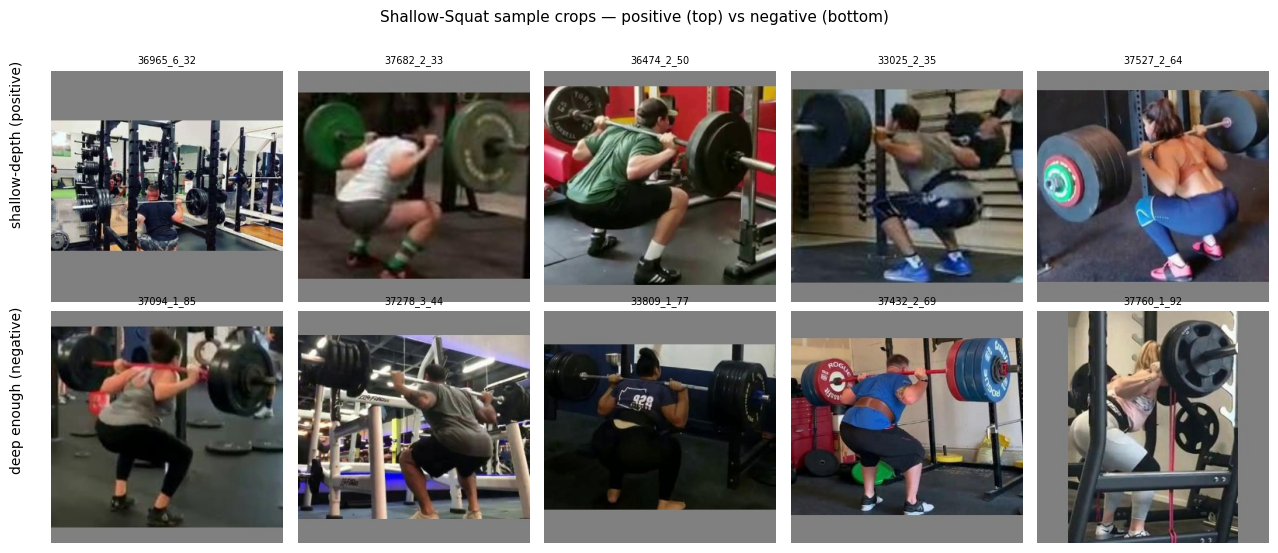

In [4]:
ZP = zipfile.ZipFile(LAB / "images.zip")


def load_crop(cid):
    with ZP.open(f"crops_unaligned/{cid}.jpg") as fh:
        return np.asarray(Image.open(io.BytesIO(fh.read())).convert("RGB"))


rng = np.random.default_rng(0)
pos_ids = [i for i in splits["train"] if labels[i] == 1]
neg_ids = [i for i in splits["train"] if labels[i] == 0]
n_show = 5
pick_pos = rng.choice(pos_ids, n_show, replace=False)
pick_neg = rng.choice(neg_ids, n_show, replace=False)

fig, axes = plt.subplots(2, n_show, figsize=(2.6 * n_show, 5.6))
for j, cid in enumerate(pick_pos):
    axes[0][j].imshow(load_crop(cid))
    axes[0][j].set_title(cid, fontsize=7)
    axes[0][j].axis("off")
for j, cid in enumerate(pick_neg):
    axes[1][j].imshow(load_crop(cid))
    axes[1][j].set_title(cid, fontsize=7)
    axes[1][j].axis("off")
axes[0][0].set_ylabel("shallow+", fontsize=10)
axes[1][0].set_ylabel("deep−", fontsize=10)
fig.text(0.02, 0.74, "shallow-depth (positive)", rotation=90, va="center", fontsize=10)
fig.text(0.02, 0.30, "deep enough (negative)", rotation=90, va="center", fontsize=10)
fig.suptitle("Shallow-Squat sample crops — positive (top) vs negative (bottom)", fontsize=11)
fig.tight_layout(rect=(0.04, 0, 1, 0.96))
plt.savefig(FIG / "shallow_squat_samples.png", dpi=130, bbox_inches="tight")
plt.show()

## 4. Crop-size distribution

Width/height over ~200 sampled crops. The crops are loosely cropped around the lifter at
varying resolution, so the pipeline resizes to a fixed `256 → CenterCrop(224)` before the
backbone (next section).

width : min 299 | median 299 | max 299
height: min 299 | median 299 | max 299


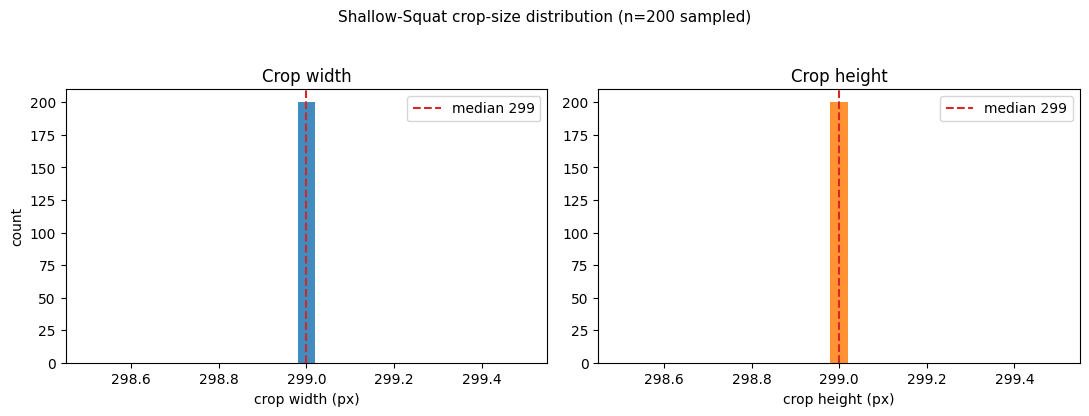

In [5]:
all_ids = list(labels.keys())
sample_ids = rng.choice(all_ids, min(200, len(all_ids)), replace=False)
ws, hs = [], []
for cid in sample_ids:
    with ZP.open(f"crops_unaligned/{cid}.jpg") as fh:
        im = Image.open(io.BytesIO(fh.read()))
        ws.append(im.width)
        hs.append(im.height)
ws = np.array(ws)
hs = np.array(hs)
print(f"width : min {ws.min()} | median {int(np.median(ws))} | max {ws.max()}")
print(f"height: min {hs.min()} | median {int(np.median(hs))} | max {hs.max()}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].hist(ws, bins=25, color="C0", alpha=0.85)
ax[0].axvline(np.median(ws), color="C3", ls="--", label=f"median {int(np.median(ws))}")
ax[0].set_xlabel("crop width (px)")
ax[0].set_ylabel("count")
ax[0].set_title("Crop width")
ax[0].legend()
ax[1].hist(hs, bins=25, color="C1", alpha=0.85)
ax[1].axvline(np.median(hs), color="C3", ls="--", label=f"median {int(np.median(hs))}")
ax[1].set_xlabel("crop height (px)")
ax[1].set_title("Crop height")
ax[1].legend()
fig.suptitle(f"Shallow-Squat crop-size distribution (n={len(sample_ids)} sampled)", fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

## Data pipeline

Per-crop transform feeding the image backbone:

1. Decode JPEG from `crops_unaligned/{id}.jpg`.
2. `Resize(256)` then `CenterCrop(224)`.
3. Normalize with ImageNet mean/std `([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])`.
4. Single sigmoid **binary head** (shallow-depth present / absent).

Unlike the OHP task there is **no barbell trajectory and no BBox stream** — this is a single
still-frame image classifier. Splits are used verbatim; F1 is reported per the paper.

## Notes
- Splits used verbatim (2542 / 529 / 540); every split id has a crop and a label.
- Near-balanced (43.9% positive) vs Squat KIE's 14% — informs the loss choice.
- Crops decoded in-memory from `images.zip`; none written to disk, none committed.